In [1]:
import pandas as pd
import tensorflow as tf
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
df = pd.read_csv("security_access_risk_dataset_RNC.csv")
df.head()

,Failed_Attempts_Last30Days,Access_Time_Deviation,Entry_Distance_From_Usual,User_Access_Tier,Access_Risk_Score
0,3.0,16.30,41.03,Standard,68.10
1,0.0,13.95,31.86,Admin,43.55
2,4.0,30.83,36.13,Standard,85.70
3,3.0,17.50,51.10,Standard,66.51
4,3.0,11.93,25.94,Standard,46.72


In [3]:
df.shape

(1545, 5)

In [4]:
df.dtypes

Failed_Attempts_Last30Days    float64
Access_Time_Deviation         float64
Entry_Distance_From_Usual     float64
User_Access_Tier               object
Access_Risk_Score             float64
dtype: object

In [5]:
df.isnull().sum()

Failed_Attempts_Last30Days    78
Access_Time_Deviation         77
Entry_Distance_From_Usual     79
User_Access_Tier              77
Access_Risk_Score             78
dtype: int64

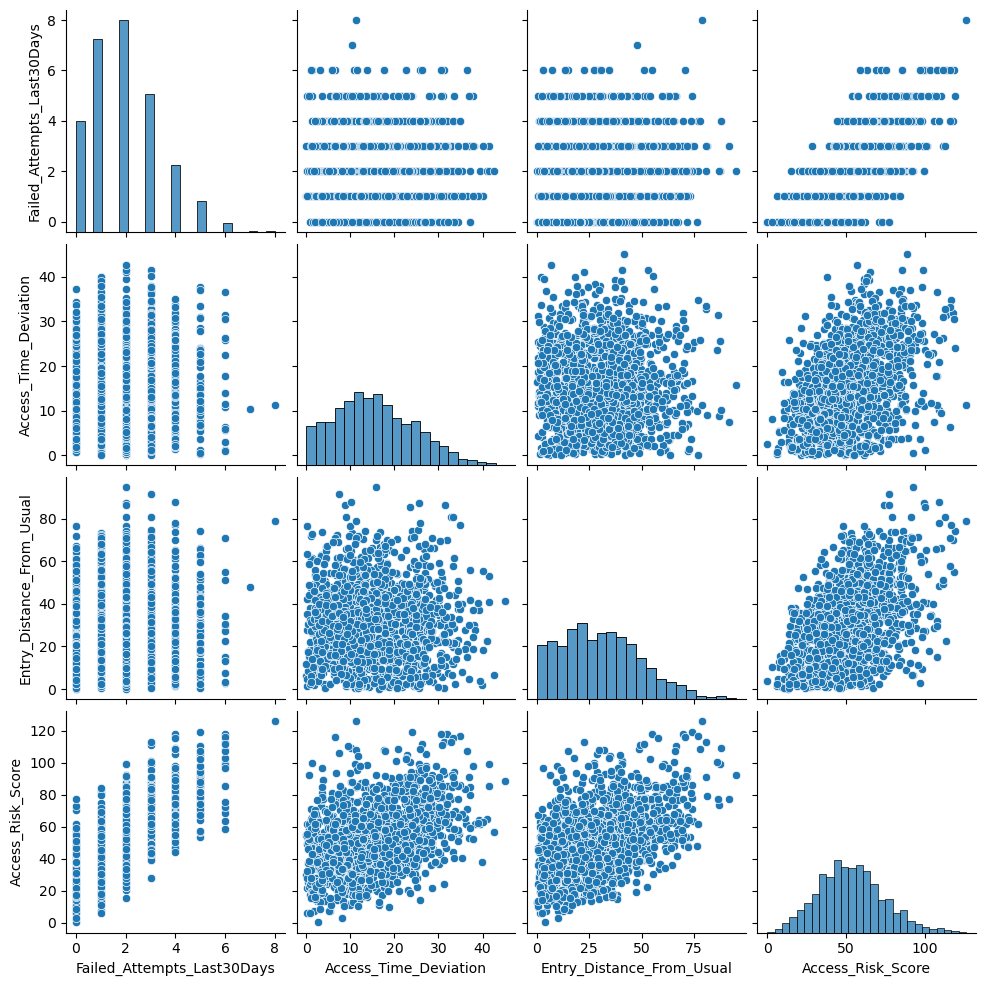

In [6]:
import seaborn as sns
sns.pairplot(data=df)

In [7]:
df = df.dropna(subset=['User_Access_Tier'])
df = df.dropna(subset=['Access_Risk_Score'])
df.isnull().sum()

Failed_Attempts_Last30Days    74
Access_Time_Deviation         71
Entry_Distance_From_Usual     69
User_Access_Tier               0
Access_Risk_Score              0
dtype: int64

In [8]:
df.dtypes

Failed_Attempts_Last30Days    float64
Access_Time_Deviation         float64
Entry_Distance_From_Usual     float64
User_Access_Tier               object
Access_Risk_Score             float64
dtype: object

In [9]:
df.head()

,Failed_Attempts_Last30Days,Access_Time_Deviation,Entry_Distance_From_Usual,User_Access_Tier,Access_Risk_Score
0,3.0,16.30,41.03,Standard,68.10
1,0.0,13.95,31.86,Admin,43.55
2,4.0,30.83,36.13,Standard,85.70
3,3.0,17.50,51.10,Standard,66.51
4,3.0,11.93,25.94,Standard,46.72


In [10]:
df['Failed_Attempts_Last30Days'] = df['Failed_Attempts_Last30Days'].fillna(0)
df.isnull().sum()

Failed_Attempts_Last30Days     0
Access_Time_Deviation         71
Entry_Distance_From_Usual     69
User_Access_Tier               0
Access_Risk_Score              0
dtype: int64

In [11]:
df['Access_Time_Deviation'] = df['Access_Time_Deviation'].fillna(df['Access_Time_Deviation'].mean())
df['Entry_Distance_From_Usual'] = df['Entry_Distance_From_Usual'].fillna(df['Entry_Distance_From_Usual'].mean())
df.isnull().sum()

Failed_Attempts_Last30Days    0
Access_Time_Deviation         0
Entry_Distance_From_Usual     0
User_Access_Tier              0
Access_Risk_Score             0
dtype: int64

In [12]:
# df = pd.get_dummies(df, columns=['User_Access_Tier'])
df["User_Access_Tier"] = df["User_Access_Tier"].map({"Admin":3,"Elevated":2,"Standard":1})
df.head()

,Failed_Attempts_Last30Days,Access_Time_Deviation,Entry_Distance_From_Usual,User_Access_Tier,Access_Risk_Score
0,3.0,16.30,41.03,1,68.10
1,0.0,13.95,31.86,3,43.55
2,4.0,30.83,36.13,1,85.70
3,3.0,17.50,51.10,1,66.51
4,3.0,11.93,25.94,1,46.72


In [13]:
train_dataset = df.sample(frac=0.8 , random_state=0)
test_dataset = df.drop(train_dataset.index)

In [14]:
train_dataset.shape

(1116, 5)

In [15]:
test_dataset.shape

(279, 5)

In [16]:
train_dataset.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Failed_Attempts_Last30Days,1116.0,1.850358,1.448057,0.00,1.0000,2.000000,3.0000,8.00
Access_Time_Deviation,1116.0,15.521678,8.618753,0.04,9.1300,15.602742,21.1025,45.15
Entry_Distance_From_Usual,1116.0,30.671689,18.262642,0.03,16.4925,30.614608,42.5425,94.80
User_Access_Tier,1116.0,1.465950,0.660008,1.00,1.0000,1.000000,2.0000,3.00
Access_Risk_Score,1116.0,52.834910,21.115664,0.01,38.4625,51.895000,66.0875,126.21


In [17]:
train_features = train_dataset.copy()
test_features = test_dataset.copy()

In [18]:
train_labels = train_features.pop('Access_Risk_Score')
test_labels = test_features.pop('Access_Risk_Score')

In [1]:
train_features.dtypes
# df = df.drop_duplicates(subset=['name', 'age'])

NameError: name 'train_features' is not defined

In [21]:
import tensorflow as tf

normalizer = tf.keras.layers.Normalization(axis = -1)
normalizer.adapt(np.array(train_features))


In [26]:
train_features = train_features.astype(np.float32)
first = np.array(train_features[:1])
with np.printoptions(precision=2, suppress=True):
  print('First example:', first)
  print()
  print('Normalized:', normalizer(first).numpy())

First example: [[ 2.   25.59 87.22  2.  ]]

Normalized: [[0.1  1.17 3.1  0.81]]


In [28]:
model = keras.Sequential([
    normalizer,
    layers.Dense(256, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(1)
    
])

In [29]:
model.compile(loss='mean_absolute_error', optimizer=tf.keras.optimizers.Adam(0.001))

In [30]:
%%time
history = model.fit(
    train_features,
    train_labels,
    validation_split=0.2,
    verbose=0, epochs=100)

CPU times: user 3.82 s, sys: 815 ms, total: 4.63 s
Wall time: 3.39 s


In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 4)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,998 (789.06 KB)

 Trainable params: 67,329 (263.00 KB)

 Non-trainable params: 9 (40.00 B)

 Optimizer params: 134,660 (526.02 KB)

In [32]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.ylim([0, 10])
  plt.xlabel('Epoch')
  plt.ylabel('Error [MPG]')
  plt.legend()
  plt.grid(True)

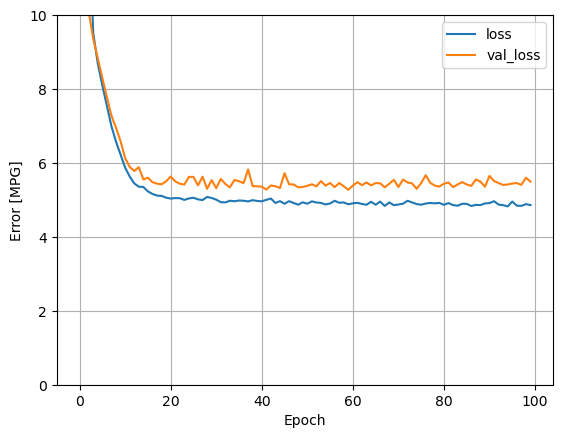

In [33]:
plot_loss(history)

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt

print("Predictions has started...")
test_predictions = model.predict(test_features).flatten()

mae = mean_absolute_error(test_labels, test_predictions)

rmse = np.sqrt(mean_squared_error(test_labels, test_predictions))

mape = mean_absolute_percentage_error(test_labels, test_predictions)

Predictions has started...
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [35]:
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.4f}")

MAE  : 5.3748
RMSE : 7.2790
MAPE : 0.1124


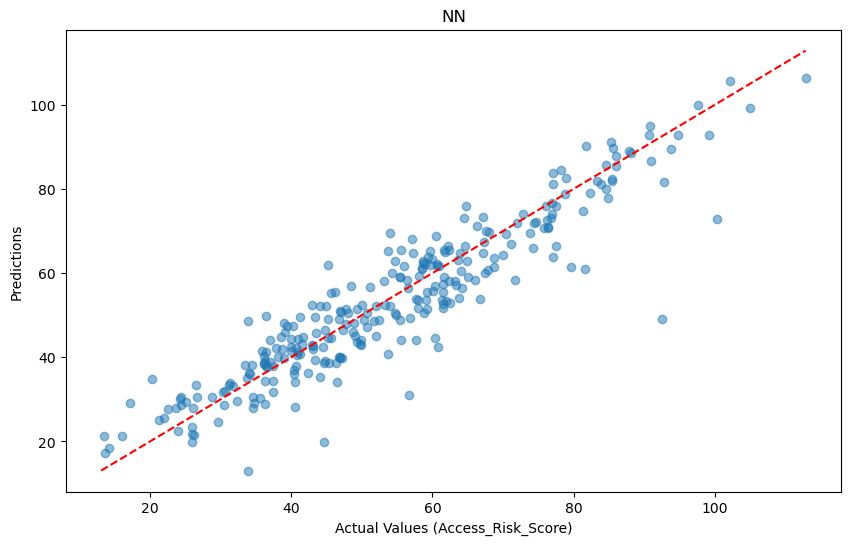

In [43]:
plt.figure(figsize=(10, 6))
plt.scatter(test_labels, test_predictions, alpha=0.5)
plt.xlabel('Actual Values (Access_Risk_Score)')
plt.ylabel('Predictions')
plt.title("NN")
# Mükemmel tahmin doğrusu (x=y)
min_val = min(min(test_labels), min(test_predictions))
max_val = max(max(test_labels), max(test_predictions))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
plt.show()

In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

X_train = train_features
X_test = test_features 

y_train = train_labels 
y_test = test_labels 


# ---------------------------------------------------------
# MODEL 1: Multiple Linear Regression
# ---------------------------------------------------------
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Linear Regression Değerlendirme
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mape_lr = mean_absolute_percentage_error(y_test, y_pred_lr)

print("--- Multiple Linear Regression Results ---")
print(f"MAE  : {mae_lr:.4f}")
print(f"RMSE : {rmse_lr:.4f}")
print(f"MAPE : {mape_lr:.4f}")
print("-" * 40)

# ---------------------------------------------------------
# MODEL 2: Decision Tree Regressor (Ağaç Modeli)
# ---------------------------------------------------------
dt_model = DecisionTreeRegressor(random_state=0)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Decision Tree Değerlendirme
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mape_dt = mean_absolute_percentage_error(y_test, y_pred_dt)

print("--- Decision Tree Regression Sonuçları ---")
print(f"MAE  : {mae_dt:.4f}")
print(f"RMSE : {rmse_dt:.4f}")
print(f"MAPE : {mape_dt:.4f}")

--- Multiple Linear Regression Results ---
MAE  : 5.3399
RMSE : 7.2211
MAPE : 0.1150
----------------------------------------
--- Decision Tree Regression Sonuçları ---
MAE  : 7.1554
RMSE : 10.2531
MAPE : 0.1510


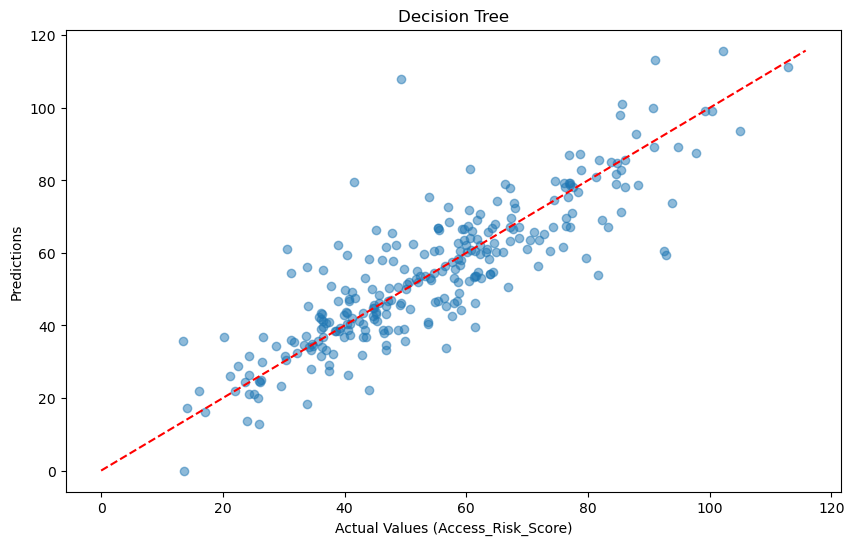

In [44]:
plt.figure(figsize=(10, 6))
plt.scatter(test_labels, y_pred_dt, alpha=0.5)
plt.xlabel('Actual Values (Access_Risk_Score)')
plt.title("Decision Tree")
plt.ylabel('Predictions')

min_val = min(min(test_labels), min(y_pred_dt))
max_val = max(max(test_labels), max(y_pred_dt))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(test_labels, y_pred_lr, alpha=0.5)
plt.xlabel('Actual Values (Access_Risk_Score)')
plt.title("Lineer Regression")
plt.ylabel('Predictions')

min_val = min(min(test_labels), min(test_predictions))
max_val = max(max(test_labels), max(test_predictions))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
plt.show()